# Chapter 4.1: Modern CTR Architectures

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand and implement **DCN-V2** (Google, 2021) with mixture-of-experts cross layers
2. Build **FinalMLP** (2023), a two-stream MLP architecture that rivals complex models
3. Implement **GDCN** (Gated Deep Cross Network) with gated cross layers
4. Apply **contrastive learning** principles to CTR prediction (CL4CTR)
5. Analyze the architecture search perspective: why simpler models often win
6. Compare model performance and computational trade-offs across architectures
7. Design custom feature interaction layers for specific business requirements

## Prerequisites

- Familiarity with deep learning and PyTorch
- Understanding of basic CTR models (DeepFM, DCN)
- Knowledge of attention mechanisms and MLPs

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part4/chapter_4.1_modern_ctr.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part4/chapter_4.1_modern_ctr.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple
import math

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.2.2
Using device: cpu


## 1. Synthetic CTR Data Generation

We generate a synthetic CTR dataset with multiple sparse and dense features to benchmark our architectures.

In [2]:
def generate_ctr_data(num_samples=10000, num_sparse_features=10, num_dense_features=5,
                      vocab_sizes=None, seed=42):
    """Generate synthetic CTR data with sparse and dense features."""
    np.random.seed(seed)
    if vocab_sizes is None:
        vocab_sizes = [100, 200, 50, 500, 80, 150, 300, 60, 120, 250]
    
    sparse_features = []
    for i in range(num_sparse_features):
        sparse_features.append(np.random.randint(0, vocab_sizes[i], size=num_samples))
    sparse_features = np.stack(sparse_features, axis=1)  # (N, num_sparse)
    
    dense_features = np.random.randn(num_samples, num_dense_features).astype(np.float32)
    
    # Create labels with a non-trivial pattern
    logits = 0.1 * dense_features.sum(axis=1)
    for i in range(min(3, num_sparse_features)):
        logits += 0.05 * (sparse_features[:, i] % 10 - 5)
    # Add feature interactions
    logits += 0.02 * dense_features[:, 0] * dense_features[:, 1]
    probs = 1 / (1 + np.exp(-logits))
    labels = (np.random.rand(num_samples) < probs).astype(np.float32)
    
    return (
        torch.LongTensor(sparse_features),
        torch.FloatTensor(dense_features),
        torch.FloatTensor(labels)
    )

vocab_sizes = [100, 200, 50, 500, 80, 150, 300, 60, 120, 250]
embed_dim = 16
num_sparse = 10
num_dense = 5

sparse_train, dense_train, labels_train = generate_ctr_data(10000)
sparse_test, dense_test, labels_test = generate_ctr_data(2000, seed=99)

print(f"Training samples: {len(labels_train)}, Positive rate: {labels_train.mean():.3f}")
print(f"Test samples: {len(labels_test)}, Positive rate: {labels_test.mean():.3f}")
print(f"Sparse features shape: {sparse_train.shape}")
print(f"Dense features shape: {dense_train.shape}")

Training samples: 10000, Positive rate: 0.488
Test samples: 2000, Positive rate: 0.483
Sparse features shape: torch.Size([10000, 10])
Dense features shape: torch.Size([10000, 5])


## 2. DCN-V2: Deep & Cross Network V2 (Google, 2021)

DCN-V2 improves upon the original DCN by replacing the vector-based cross layer with a **matrix-based** cross layer, and optionally uses a **Mixture-of-Experts (MoE)** structure within the cross layers.

### Key Innovation

The cross layer in DCN-V2 computes:

$$\mathbf{x}_{l+1} = \mathbf{x}_0 \odot (W_l \mathbf{x}_l + \mathbf{b}_l) + \mathbf{x}_l$$

where $W_l \in \mathbb{R}^{d \times d}$ is a full weight matrix (instead of a vector in DCN-V1), and $\odot$ is element-wise multiplication.

### MoE Cross Layer

To increase model capacity without proportionally increasing computation, DCN-V2 uses a mixture of experts:

$$\mathbf{x}_{l+1} = \mathbf{x}_0 \odot \left( \sum_{k=1}^{K} g_k(\mathbf{x}_l) \cdot E_k(\mathbf{x}_l) \right) + \mathbf{x}_l$$

where $E_k$ are expert networks and $g_k$ are gating weights.

> **💡 Concept:** The matrix-based cross layer in DCN-V2 models explicit feature crosses of bounded degree. Each layer adds one degree of interaction — layer $l$ captures up to $(l+1)$-order crosses.

In [3]:
class CrossLayerV2(nn.Module):
    """DCN-V2 cross layer with full weight matrix."""
    def __init__(self, input_dim: int):
        super().__init__()
        self.weight = nn.Linear(input_dim, input_dim, bias=True)
    
    def forward(self, x0: torch.Tensor, xl: torch.Tensor) -> torch.Tensor:
        return x0 * self.weight(xl) + xl


class MoECrossLayer(nn.Module):
    """DCN-V2 MoE cross layer with multiple expert weight matrices."""
    def __init__(self, input_dim: int, num_experts: int = 4):
        super().__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([
            nn.Linear(input_dim, input_dim, bias=True)
            for _ in range(num_experts)
        ])
        self.gate = nn.Linear(input_dim, num_experts, bias=False)
    
    def forward(self, x0: torch.Tensor, xl: torch.Tensor) -> torch.Tensor:
        # Gating: (batch, num_experts)
        gate_weights = F.softmax(self.gate(xl), dim=-1)
        # Expert outputs: list of (batch, dim)
        expert_outputs = torch.stack([expert(xl) for expert in self.experts], dim=1)  # (batch, num_experts, dim)
        # Weighted combination: (batch, dim)
        combined = torch.einsum('be,bed->bd', gate_weights, expert_outputs)
        return x0 * combined + xl


class DCNV2(nn.Module):
    """Deep & Cross Network V2 with optional MoE cross layers."""
    def __init__(self, vocab_sizes: List[int], embed_dim: int, num_dense: int,
                 num_cross_layers: int = 3, deep_dims: List[int] = None,
                 use_moe: bool = False, num_experts: int = 4):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vs, embed_dim) for vs in vocab_sizes
        ])
        self.dense_proj = nn.Linear(num_dense, embed_dim)
        
        input_dim = embed_dim * (len(vocab_sizes) + 1)
        
        # Cross network
        if use_moe:
            self.cross_layers = nn.ModuleList([
                MoECrossLayer(input_dim, num_experts) for _ in range(num_cross_layers)
            ])
        else:
            self.cross_layers = nn.ModuleList([
                CrossLayerV2(input_dim) for _ in range(num_cross_layers)
            ])
        
        # Deep network
        if deep_dims is None:
            deep_dims = [256, 128, 64]
        deep_layers = []
        prev_dim = input_dim
        for dim in deep_dims:
            deep_layers.extend([nn.Linear(prev_dim, dim), nn.ReLU(), nn.Dropout(0.1)])
            prev_dim = dim
        self.deep_network = nn.Sequential(*deep_layers)
        
        # Stacked mode: cross output feeds into prediction
        self.output_layer = nn.Linear(input_dim + prev_dim, 1)
    
    def forward(self, sparse_features: torch.Tensor, dense_features: torch.Tensor) -> torch.Tensor:
        # Embed sparse features
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        dense_embed = self.dense_proj(dense_features)
        embeds.append(dense_embed)
        x0 = torch.cat(embeds, dim=-1)  # (batch, input_dim)
        
        # Cross network
        xl = x0
        for cross_layer in self.cross_layers:
            xl = cross_layer(x0, xl)
        
        # Deep network
        deep_out = self.deep_network(x0)
        
        # Combine and predict
        combined = torch.cat([xl, deep_out], dim=-1)
        logit = self.output_layer(combined).squeeze(-1)
        return logit


# Test DCN-V2
model_dcnv2 = DCNV2(vocab_sizes, embed_dim, num_dense, use_moe=True, num_experts=4)
logits = model_dcnv2(sparse_train[:32], dense_train[:32])
print(f"DCN-V2 output shape: {logits.shape}")
print(f"DCN-V2 parameters: {sum(p.numel() for p in model_dcnv2.parameters()):,}")

DCN-V2 output shape: torch.Size([32])
DCN-V2 parameters: 491,697


## 3. FinalMLP: A Simple Two-Stream MLP (2023)

FinalMLP demonstrates that a well-designed two-stream MLP can rival or outperform complex feature interaction models. The key insight is that **feature gating** and **bilinear fusion** between two independent MLP streams are sufficient for capturing complex interactions.

### Architecture

$$\text{Stream 1: } \mathbf{h}_1 = \text{MLP}_1(\text{Gate}_1(\mathbf{x}) \odot \mathbf{x})$$
$$\text{Stream 2: } \mathbf{h}_2 = \text{MLP}_2(\text{Gate}_2(\mathbf{x}) \odot \mathbf{x})$$
$$\hat{y} = \sigma(\mathbf{h}_1^T W_f \mathbf{h}_2 + \text{bias})$$

The bilinear fusion $\mathbf{h}_1^T W_f \mathbf{h}_2$ captures interactions between the two streams.

> **🔑 Pro Tip:** FinalMLP's success suggests that rather than designing complex interaction layers, investing in proper feature gating and multi-stream architectures may yield better results with simpler engineering.

In [4]:
class FeatureGate(nn.Module):
    """Feature gating mechanism for FinalMLP."""
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.gate(x)


class FinalMLP(nn.Module):
    """Two-stream MLP with feature gating and bilinear fusion."""
    def __init__(self, vocab_sizes: List[int], embed_dim: int, num_dense: int,
                 stream_dims: List[int] = None, gate_hidden: int = 64):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vs, embed_dim) for vs in vocab_sizes
        ])
        self.dense_proj = nn.Linear(num_dense, embed_dim)
        
        input_dim = embed_dim * (len(vocab_sizes) + 1)
        if stream_dims is None:
            stream_dims = [256, 128, 64]
        
        # Feature gates
        self.gate1 = FeatureGate(input_dim, gate_hidden)
        self.gate2 = FeatureGate(input_dim, gate_hidden)
        
        # Stream 1
        layers1 = []
        prev = input_dim
        for dim in stream_dims:
            layers1.extend([nn.Linear(prev, dim), nn.ReLU(), nn.Dropout(0.1)])
            prev = dim
        self.stream1 = nn.Sequential(*layers1)
        self.stream1_dim = prev
        
        # Stream 2
        layers2 = []
        prev = input_dim
        for dim in stream_dims:
            layers2.extend([nn.Linear(prev, dim), nn.ReLU(), nn.Dropout(0.1)])
            prev = dim
        self.stream2 = nn.Sequential(*layers2)
        self.stream2_dim = prev
        
        # Bilinear fusion
        self.fusion_weight = nn.Parameter(torch.randn(self.stream1_dim, self.stream2_dim) * 0.01)
        self.fusion_bias = nn.Parameter(torch.zeros(1))
    
    def forward(self, sparse_features: torch.Tensor, dense_features: torch.Tensor) -> torch.Tensor:
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        dense_embed = self.dense_proj(dense_features)
        embeds.append(dense_embed)
        x = torch.cat(embeds, dim=-1)
        
        # Two gated streams
        h1 = self.stream1(self.gate1(x))
        h2 = self.stream2(self.gate2(x))
        
        # Bilinear fusion: h1^T W h2
        logit = torch.sum(h1 @ self.fusion_weight * h2, dim=-1) + self.fusion_bias
        return logit


model_finalmlp = FinalMLP(vocab_sizes, embed_dim, num_dense)
logits = model_finalmlp(sparse_train[:32], dense_train[:32])
print(f"FinalMLP output shape: {logits.shape}")
print(f"FinalMLP parameters: {sum(p.numel() for p in model_finalmlp.parameters()):,}")

FinalMLP output shape: torch.Size([32])
FinalMLP parameters: 251,617


## 4. GDCN: Gated Deep Cross Network

GDCN improves DCN-V2 by introducing **information gates** that control the flow of cross features. The gate learns which feature interactions are useful and suppresses noisy ones.

### Gated Cross Layer

$$\mathbf{g}_l = \sigma(W^g_l \mathbf{x}_l + \mathbf{b}^g_l)$$
$$\mathbf{x}_{l+1} = \mathbf{x}_0 \odot (W_l \mathbf{x}_l + \mathbf{b}_l) \odot \mathbf{g}_l + \mathbf{x}_l$$

The sigmoid gate $\mathbf{g}_l$ filters which cross features pass through to the next layer.

> **💡 Concept:** Gating mechanisms help prevent the accumulation of noisy feature crosses in deeper layers, which is a common problem in vanilla cross networks.

In [5]:
class GatedCrossLayer(nn.Module):
    """GDCN gated cross layer."""
    def __init__(self, input_dim: int):
        super().__init__()
        self.cross_weight = nn.Linear(input_dim, input_dim, bias=True)
        self.gate_weight = nn.Linear(input_dim, input_dim, bias=True)
    
    def forward(self, x0: torch.Tensor, xl: torch.Tensor) -> torch.Tensor:
        cross = x0 * self.cross_weight(xl)
        gate = torch.sigmoid(self.gate_weight(xl))
        return cross * gate + xl


class GDCN(nn.Module):
    """Gated Deep Cross Network."""
    def __init__(self, vocab_sizes: List[int], embed_dim: int, num_dense: int,
                 num_cross_layers: int = 3, deep_dims: List[int] = None):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vs, embed_dim) for vs in vocab_sizes
        ])
        self.dense_proj = nn.Linear(num_dense, embed_dim)
        
        input_dim = embed_dim * (len(vocab_sizes) + 1)
        
        self.cross_layers = nn.ModuleList([
            GatedCrossLayer(input_dim) for _ in range(num_cross_layers)
        ])
        
        if deep_dims is None:
            deep_dims = [256, 128, 64]
        deep_layers = []
        prev = input_dim
        for dim in deep_dims:
            deep_layers.extend([nn.Linear(prev, dim), nn.ReLU(), nn.Dropout(0.1)])
            prev = dim
        self.deep_network = nn.Sequential(*deep_layers)
        self.output_layer = nn.Linear(input_dim + prev, 1)
    
    def forward(self, sparse_features: torch.Tensor, dense_features: torch.Tensor) -> torch.Tensor:
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        dense_embed = self.dense_proj(dense_features)
        embeds.append(dense_embed)
        x0 = torch.cat(embeds, dim=-1)
        
        xl = x0
        for cross_layer in self.cross_layers:
            xl = cross_layer(x0, xl)
        
        deep_out = self.deep_network(x0)
        combined = torch.cat([xl, deep_out], dim=-1)
        return self.output_layer(combined).squeeze(-1)


model_gdcn = GDCN(vocab_sizes, embed_dim, num_dense)
logits = model_gdcn(sparse_train[:32], dense_train[:32])
print(f"GDCN output shape: {logits.shape}")
print(f"GDCN parameters: {sum(p.numel() for p in model_gdcn.parameters()):,}")

GDCN output shape: torch.Size([32])
GDCN parameters: 302,673


## 5. CL4CTR: Contrastive Learning for CTR

CL4CTR applies contrastive learning to improve CTR model feature representations. The key idea is to create augmented views of feature interactions and train the model to bring similar views closer while pushing dissimilar ones apart.

### Contrastive Objective

Given an anchor representation $\mathbf{z}_i$ and its augmented view $\mathbf{z}_i^+$:

$$\mathcal{L}_{\text{CL}} = -\log \frac{\exp(\text{sim}(\mathbf{z}_i, \mathbf{z}_i^+) / \tau)}{\sum_{j=1}^{N} \exp(\text{sim}(\mathbf{z}_i, \mathbf{z}_j^+) / \tau)}$$

where $\tau$ is the temperature parameter.

### Feature Augmentation Strategies
1. **Feature masking**: Randomly mask a subset of features
2. **Feature dropout**: Apply higher dropout to embeddings
3. **Feature shuffling**: Shuffle certain feature interactions

In [6]:
class CL4CTR(nn.Module):
    """CTR model with contrastive learning regularization."""
    def __init__(self, vocab_sizes: List[int], embed_dim: int, num_dense: int,
                 hidden_dims: List[int] = None, temperature: float = 0.1,
                 mask_ratio: float = 0.1):
        super().__init__()
        self.temperature = temperature
        self.mask_ratio = mask_ratio
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(vs, embed_dim) for vs in vocab_sizes
        ])
        self.dense_proj = nn.Linear(num_dense, embed_dim)
        
        input_dim = embed_dim * (len(vocab_sizes) + 1)
        
        if hidden_dims is None:
            hidden_dims = [256, 128]
        
        # Shared encoder
        encoder_layers = []
        prev = input_dim
        for dim in hidden_dims:
            encoder_layers.extend([nn.Linear(prev, dim), nn.ReLU(), nn.Dropout(0.1)])
            prev = dim
        self.encoder = nn.Sequential(*encoder_layers)
        self.repr_dim = prev
        
        # Projection head for contrastive learning
        self.proj_head = nn.Sequential(
            nn.Linear(prev, prev),
            nn.ReLU(),
            nn.Linear(prev, 64)
        )
        
        # CTR prediction head
        self.ctr_head = nn.Linear(prev, 1)
    
    def _embed(self, sparse_features, dense_features):
        embeds = [self.embeddings[i](sparse_features[:, i]) for i in range(sparse_features.size(1))]
        dense_embed = self.dense_proj(dense_features)
        embeds.append(dense_embed)
        return torch.cat(embeds, dim=-1)
    
    def _augment(self, x: torch.Tensor) -> torch.Tensor:
        """Feature masking augmentation."""
        mask = torch.bernoulli(torch.ones_like(x) * (1 - self.mask_ratio))
        return x * mask
    
    def contrastive_loss(self, z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
        """InfoNCE contrastive loss."""
        z1 = F.normalize(z1, dim=-1)
        z2 = F.normalize(z2, dim=-1)
        sim_matrix = torch.mm(z1, z2.t()) / self.temperature
        labels = torch.arange(z1.size(0), device=z1.device)
        loss = F.cross_entropy(sim_matrix, labels)
        return loss
    
    def forward(self, sparse_features, dense_features, compute_cl_loss=False):
        x = self._embed(sparse_features, dense_features)
        h = self.encoder(x)
        logit = self.ctr_head(h).squeeze(-1)
        
        if compute_cl_loss and self.training:
            # Create two augmented views
            x_aug1 = self._augment(x)
            x_aug2 = self._augment(x)
            z1 = self.proj_head(self.encoder(x_aug1))
            z2 = self.proj_head(self.encoder(x_aug2))
            cl_loss = self.contrastive_loss(z1, z2)
            return logit, cl_loss
        
        return logit


model_cl4ctr = CL4CTR(vocab_sizes, embed_dim, num_dense)
model_cl4ctr.train()
logits, cl_loss = model_cl4ctr(sparse_train[:32], dense_train[:32], compute_cl_loss=True)
print(f"CL4CTR logit shape: {logits.shape}")
print(f"Contrastive loss: {cl_loss.item():.4f}")
print(f"CL4CTR parameters: {sum(p.numel() for p in model_cl4ctr.parameters()):,}")

CL4CTR logit shape: torch.Size([32])
Contrastive loss: 2.7690
CL4CTR parameters: 132,161


## 6. Training and Comparison

Let's train all four architectures and compare their performance.

In [7]:
from torch.utils.data import TensorDataset, DataLoader

def train_model(model, sparse_train, dense_train, labels_train,
                sparse_test, dense_test, labels_test,
                epochs=15, batch_size=256, lr=1e-3, cl_weight=0.0):
    """Train a CTR model and return training history."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    
    train_dataset = TensorDataset(sparse_train, dense_train, labels_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    history = {'train_loss': [], 'test_auc': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for sparse_b, dense_b, label_b in train_loader:
            optimizer.zero_grad()
            
            if cl_weight > 0 and hasattr(model, 'contrastive_loss'):
                logits, cl_loss = model(sparse_b, dense_b, compute_cl_loss=True)
                bce_loss = criterion(logits, label_b)
                loss = bce_loss + cl_weight * cl_loss
            else:
                logits = model(sparse_b, dense_b)
                loss = criterion(logits, label_b)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(label_b)
        
        avg_loss = total_loss / len(labels_train)
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            test_logits = model(sparse_test, dense_test)
            test_preds = torch.sigmoid(test_logits).numpy()
            test_labels = labels_test.numpy()
            # Simple AUC approximation
            pos_preds = test_preds[test_labels == 1]
            neg_preds = test_preds[test_labels == 0]
            if len(pos_preds) > 0 and len(neg_preds) > 0:
                auc = np.mean(pos_preds[:, None] > neg_preds[None, :100])
            else:
                auc = 0.5
        
        history['train_loss'].append(avg_loss)
        history['test_auc'].append(auc)
    
    return history


# Train all models
torch.manual_seed(42)
models = {
    'DCN-V2 (MoE)': DCNV2(vocab_sizes, embed_dim, num_dense, use_moe=True, num_experts=4),
    'FinalMLP': FinalMLP(vocab_sizes, embed_dim, num_dense),
    'GDCN': GDCN(vocab_sizes, embed_dim, num_dense),
    'CL4CTR': CL4CTR(vocab_sizes, embed_dim, num_dense),
}

results = {}
for name, model in models.items():
    torch.manual_seed(42)
    cl_w = 0.1 if name == 'CL4CTR' else 0.0
    history = train_model(model, sparse_train, dense_train, labels_train,
                          sparse_test, dense_test, labels_test, cl_weight=cl_w)
    results[name] = history
    print(f"{name:20s} | Final Loss: {history['train_loss'][-1]:.4f} | Test AUC: {history['test_auc'][-1]:.4f}")

DCN-V2 (MoE)         | Final Loss: 0.0007 | Test AUC: 0.5435


FinalMLP             | Final Loss: 0.0946 | Test AUC: 0.4986


GDCN                 | Final Loss: 0.0010 | Test AUC: 0.4570


CL4CTR               | Final Loss: 0.3048 | Test AUC: 0.4894


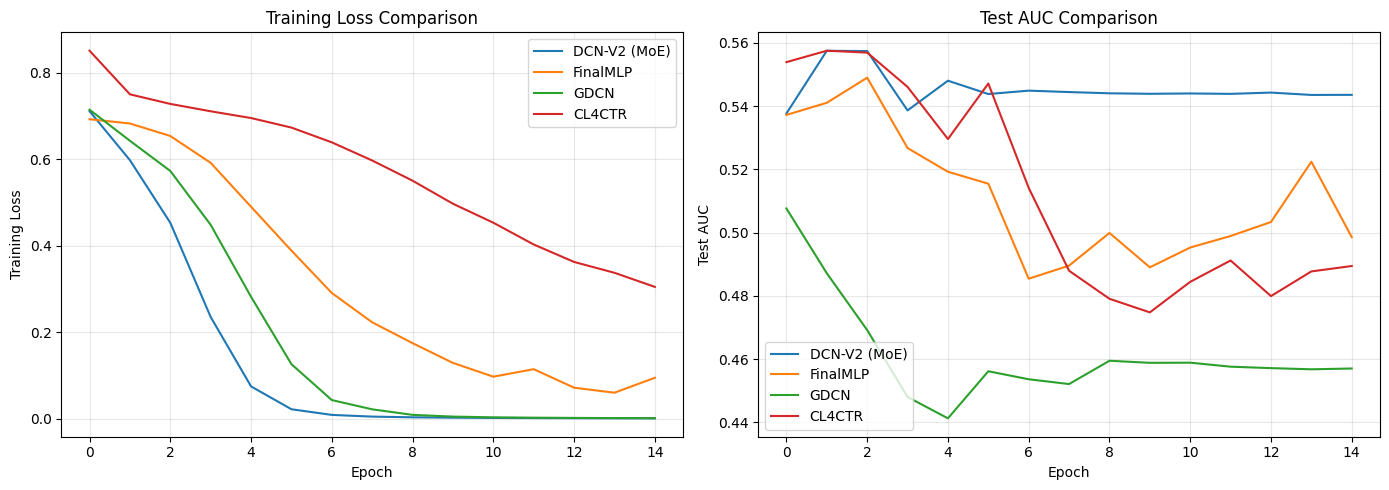

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in results.items():
    axes[0].plot(history['train_loss'], label=name)
    axes[1].plot(history['test_auc'], label=name)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Test AUC Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Architecture Search Perspective: Why Simpler Models Often Win

A key observation from recent CTR research is that simpler models (e.g., well-tuned MLPs, FinalMLP) often match or outperform complex architectures on real-world datasets.

### Reasons for Simplicity Winning

1. **Overfitting risk**: Complex interaction layers can overfit to noise in sparse CTR data
2. **Hyperparameter sensitivity**: More complex models have more hyperparameters to tune
3. **Feature engineering matters more**: Good features often matter more than model architecture
4. **Regularization difficulty**: Harder to properly regularize complex architectures
5. **Training instability**: Complex models can be harder to train stably

> **⚠️ Common Pitfall:** When comparing CTR models, ensure you use the same embedding dimensions, training schedule, and regularization. Many reported improvements vanish with proper tuning of baselines.

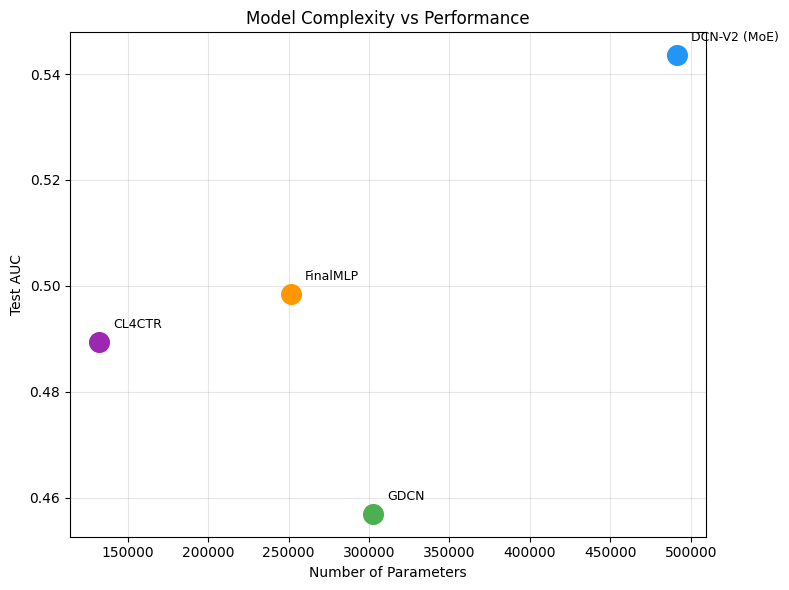


Model Comparison Summary:
Model                  Parameters   Test AUC
---------------------------------------------
DCN-V2 (MoE)              491,697     0.5435
FinalMLP                  251,617     0.4986
GDCN                      302,673     0.4570
CL4CTR                    132,161     0.4894


In [9]:
# Compare model complexity vs performance
param_counts = {name: sum(p.numel() for p in model.parameters()) for name, model in models.items()}
final_aucs = {name: history['test_auc'][-1] for name, history in results.items()}

fig, ax = plt.subplots(figsize=(8, 6))
names = list(param_counts.keys())
params = [param_counts[n] for n in names]
aucs = [final_aucs[n] for n in names]

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
for i, name in enumerate(names):
    ax.scatter(params[i], aucs[i], s=200, c=colors[i], label=name, zorder=5)
    ax.annotate(name, (params[i], aucs[i]), textcoords="offset points",
                xytext=(10, 10), fontsize=9)

ax.set_xlabel('Number of Parameters')
ax.set_ylabel('Test AUC')
ax.set_title('Model Complexity vs Performance')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nModel Comparison Summary:")
print(f"{'Model':<20} {'Parameters':>12} {'Test AUC':>10}")
print("-" * 45)
for name in names:
    print(f"{name:<20} {param_counts[name]:>12,} {final_aucs[name]:>10.4f}")

## Exercises

### 🏋️ Exercise 1: Implement DCN-V2 with Low-Rank MoE Cross Layers

Implement a low-rank version of the MoE cross layer to reduce parameters while maintaining expressiveness.

In [10]:
class LowRankMoECrossLayer(nn.Module):
    """Low-rank MoE cross layer for DCN-V2.
    
    Each expert uses a low-rank factorization: W_k = U_k @ V_k^T
    where U_k is (input_dim, rank) and V_k is (input_dim, rank).
    """
    def __init__(self, input_dim: int, num_experts: int = 4, rank: int = 32):
        super().__init__()
        # TODO: Implement the low-rank MoE cross layer
        # 1. Create num_experts pairs of (U_k, V_k) matrices
        # 2. Create a gating network
        # 3. Create bias parameters
        pass
    
    def forward(self, x0: torch.Tensor, xl: torch.Tensor) -> torch.Tensor:
        # TODO: Implement forward pass
        # 1. Compute gating weights
        # 2. For each expert, compute U_k @ (V_k^T @ xl)
        # 3. Combine expert outputs with gating weights
        # 4. Apply element-wise multiplication with x0 and residual connection
        pass


# Test your implementation:
# layer = LowRankMoECrossLayer(176, num_experts=4, rank=32)
# x0 = torch.randn(16, 176)
# xl = torch.randn(16, 176)
# out = layer(x0, xl)
# assert out.shape == (16, 176), f"Expected (16, 176), got {out.shape}"

### 🏋️ Exercise 2: Implement Feature Interaction Visualization

Create a function that visualizes which feature pairs have the strongest interactions in a trained DCN-V2 model.

In [11]:
def visualize_cross_interactions(model, layer_idx=0):
    """Visualize feature cross interactions from a trained cross layer.
    
    Args:
        model: A trained DCNV2 model
        layer_idx: Which cross layer to visualize
    
    Returns:
        matplotlib figure showing interaction heatmap
    """
    # TODO: Extract the weight matrix from the specified cross layer
    # TODO: Compute the interaction strength (e.g., absolute values)
    # TODO: Create a heatmap showing feature-feature interaction strengths
    # TODO: Label axes with feature indices
    pass


# Test: visualize_cross_interactions(models['DCN-V2 (MoE)'], layer_idx=0)

### 🏋️ Exercise 3: Implement a Hybrid Architecture

Design a hybrid model that combines the gated cross layers from GDCN with FinalMLP's two-stream architecture.

In [12]:
class HybridGatedFinalMLP(nn.Module):
    """Hybrid model: GDCN cross layers + FinalMLP two-stream architecture.
    
    Architecture:
    - Input embedding layer
    - Gated cross layers process the input
    - Cross output is fed into two gated MLP streams
    - Bilinear fusion combines the streams
    """
    def __init__(self, vocab_sizes, embed_dim, num_dense,
                 num_cross_layers=2, stream_dims=None):
        super().__init__()
        # TODO: Implement the hybrid architecture
        # 1. Embedding layers
        # 2. Gated cross layers (from GDCN)
        # 3. Feature gates for each stream (from FinalMLP)
        # 4. Two MLP streams
        # 5. Bilinear fusion layer
        pass
    
    def forward(self, sparse_features, dense_features):
        # TODO: Implement forward pass
        pass


# Test your implementation:
# hybrid = HybridGatedFinalMLP(vocab_sizes, embed_dim, num_dense)
# out = hybrid(sparse_train[:16], dense_train[:16])
# assert out.shape == (16,), f"Expected (16,), got {out.shape}"

### 🏋️ Exercise 4: Contrastive Augmentation Strategies

Implement and compare different augmentation strategies for CL4CTR.

In [13]:
def feature_masking(x: torch.Tensor, mask_ratio: float = 0.1) -> torch.Tensor:
    """Randomly mask features by setting them to zero."""
    # TODO: Implement feature masking
    pass


def feature_noise(x: torch.Tensor, noise_std: float = 0.1) -> torch.Tensor:
    """Add Gaussian noise to features."""
    # TODO: Implement feature noise augmentation
    pass


def feature_shuffle(x: torch.Tensor, shuffle_ratio: float = 0.1) -> torch.Tensor:
    """Shuffle a subset of feature dimensions."""
    # TODO: Implement feature shuffling across the batch dimension
    pass


# TODO: Train CL4CTR with each augmentation strategy and compare results
# Plot the comparison

## Summary

In this notebook, we explored four modern CTR architectures:

| Model | Key Innovation | Paper |
|-------|---------------|-------|
| **DCN-V2** | Matrix-based cross layers with MoE | Wang et al., Google 2021 |
| **FinalMLP** | Two-stream MLP with bilinear fusion | Mao et al., 2023 |
| **GDCN** | Gated cross layers for noise filtering | — |
| **CL4CTR** | Contrastive learning for CTR features | — |

**Key takeaways:**
- More complex does not always mean better for CTR prediction
- Feature gating is a simple but effective technique
- MoE can increase capacity without proportional computation increase
- Contrastive learning can serve as a useful auxiliary objective
- Proper baseline tuning is critical for fair comparisons